In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
matricula = pd.read_csv("matricula_sistemas.csv")
matricula.describe()

,num_postulantes,becas_otorgadas,tasa_desercion_anterior,campania_difusion,num_matriculados
count,24.000000,24.000000,24.000000,24.000000,24.000000
mean,231.125000,18.250000,0.129917,0.500000,137.083333
std,41.277757,6.917212,0.021055,0.510754,34.122435
min,146.000000,8.000000,0.096000,0.000000,75.000000
25%,200.250000,12.750000,0.110750,0.000000,111.500000
50%,222.500000,17.500000,0.127500,0.500000,137.000000
75%,261.250000,24.250000,0.150250,1.000000,161.500000
max,311.000000,30.000000,0.167000,1.000000,198.000000


In [3]:
col = matricula["num_matriculados"]
print("Media:", col.mean())
print("Mediana:", col.median())
print("Moda:", col.mode().tolist())
print("Rango:", col.max() - col.min())
print("Varianza:", col.var())
print("Desviacion estandar:", col.std())

Media: 137.08333333333334
Mediana: 137.0
Moda: [120, 137, 160]
Rango: 123
Varianza: 1164.340579710145
Desviacion estandar: 34.12243513745971


In [4]:
matricula.corr(numeric_only=True)["num_matriculados"]

num_postulantes            0.951145
becas_otorgadas            0.895512
tasa_desercion_anterior   -0.436143
campania_difusion          0.496448
num_matriculados           1.000000
Name: num_matriculados, dtype: float64

## Predicción lineal y comparación de errores

Se comparan dos valores de la pendiente: **w = 5** y **w = 32**,
manteniendo el intercepto fijo en **b = 137.1**.

La predicción se calcula mediante:

$$
\hat{y} = w \times x + b
$$

El error se calcula como matrícula real menos matrícula predicha:

$$
e = y - \hat{y}
$$

Las predicciones se redondean a un decimal antes de calcular
el error, siguiendo el ejemplo del ejercicio.

| Semestre | Matrícula real | Predicción w = 5 | Error w = 5 | Predicción w = 32 | Error w = 32 |
|---|---:|---:|---:|---:|---:|
| 2015-I | 120 | 134.7 | -14.7 | 121.4 | -1.4 |
| 2015-II | 88 | 130.8 | -42.8 | 96.8 | -8.8 |
| 2016-I | 101 | 130.9 | -29.9 | 97.4 | 3.6 |
| 2016-II | 75 | 126.8 | -51.8 | 71.2 | 3.8 |
| 2017-I | 112 | 133.1 | -21.1 | 111.5 | 0.5 |
| 2017-II | 98 | 133.0 | -35.0 | 110.5 | -12.5 |

### Interpretación

Con **w = 5**, los errores son grandes y negativos en todos los
semestres: el modelo predice más matriculados que los reales.

Con **w = 32**, los errores tienen menor valor absoluto en los
seis semestres. Por lo tanto, **w = 32 predice mejor la matrícula**.

Un error negativo indica una sobreestimación y un error positivo
indica una subestimación.

## 4.3. Visualizando la función de error de un modelo real

Se normaliza el número de postulantes y se prueban 100 valores
de la pendiente w entre 0 y 60, manteniendo el intercepto b = 137.1.

Para cada pendiente se calcula el error cuadrático medio (MSE).
Un MSE menor indica que las predicciones se acercan más a los
valores reales.

In [6]:
postulantes = matricula["num_postulantes"]
postulantes_norm = (postulantes - postulantes.mean()) / postulantes.std()
matriculados = matricula["num_matriculados"].astype(float)

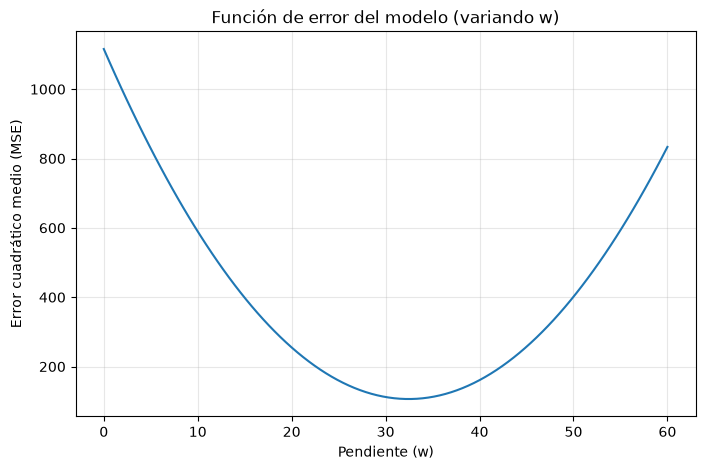

In [8]:
b_fijo = 137.1
valores_w = np.linspace(0, 60, 100)
errores = []

for w in valores_w:
    prediccion = w * postulantes_norm + b_fijo
    mse = np.mean((prediccion - matriculados) ** 2)
    errores.append(mse)

plt.figure(figsize=(8, 5))
plt.plot(valores_w, errores)
plt.xlabel("Pendiente (w)")
plt.ylabel("Error cuadrático medio (MSE)")
plt.title("Función de error del modelo (variando w)")
plt.grid(alpha=0.3)
plt.show()

### Interpretación de la gráfica

El error disminuye conforme la pendiente se aproxima al mínimo,
ubicado cerca de w = 32.4. Al alejarse de ese valor, el error aumenta.

Cada punto de la curva representa el MSE de las predicciones
para los 24 semestres utilizando una pendiente diferente.

Esto explica por qué w = 32 dio mejores resultados que w = 5
en las tablas anteriores: se encuentra más cerca de la pendiente
que minimiza el error.

## 4.4. Descenso de gradiente

Se inicia con w = 0 y b = 0. En cada paso se calculan los
gradientes y se actualizan ambos parámetros para reducir el MSE,
utilizando una tasa de aprendizaje de 0.3.

In [9]:
w, b = 0.0, 0.0
tasa_aprendizaje = 0.3
n = len(postulantes_norm)

for paso in range(1, 11):
    prediccion = w * postulantes_norm + b
    error = prediccion - matriculados
    mse = np.mean(error ** 2)

    gradiente_w = (2 / n) * np.sum(error * postulantes_norm)
    gradiente_b = (2 / n) * np.sum(error)

    w = w - tasa_aprendizaje * gradiente_w
    b = b - tasa_aprendizaje * gradiente_b

    print(
        f"Paso {paso}: MSE antes del ajuste={mse:.2f}, "
        f"w actualizado={w:.4f}, b actualizado={b:.4f}"
    )

print(f"\nValores finales: w={w:.4f}, b={b:.4f}")

Paso 1: MSE antes del ajuste=19907.67, w actualizado=18.6618, b actualizado=82.2500
Paso 2: MSE antes del ajuste=3295.39, w actualizado=26.5931, b actualizado=115.1500
Paso 3: MSE antes del ajuste=620.37, w actualizado=29.9639, b actualizado=128.3100
Paso 4: MSE antes del ajuste=189.29, w actualizado=31.3965, b actualizado=133.5740
Paso 5: MSE antes del ajuste=119.76, w actualizado=32.0053, b actualizado=135.6796
Paso 6: MSE antes del ajuste=108.53, w actualizado=32.2641, b actualizado=136.5218
Paso 7: MSE antes del ajuste=106.72, w actualizado=32.3741, b actualizado=136.8587
Paso 8: MSE antes del ajuste=106.42, w actualizado=32.4208, b actualizado=136.9935
Paso 9: MSE antes del ajuste=106.37, w actualizado=32.4407, b actualizado=137.0474
Paso 10: MSE antes del ajuste=106.37, w actualizado=32.4491, b actualizado=137.0690

Valores finales: w=32.4491, b=137.0690


In [10]:
X_simple = postulantes_norm.values.reshape(-1, 1)

comprobacion = LinearRegression().fit(X_simple, matriculados)

w_sk = comprobacion.coef_[0]
b_sk = comprobacion.intercept_

print(f"Descenso manual: w={w:.4f}, b={b:.4f}")
print(f"Scikit-learn:   w={w_sk:.4f}, b={b_sk:.4f}")

Descenso manual: w=32.4491, b=137.0690
Scikit-learn:   w=32.4554, b=137.0833


### Interpretación

El descenso de gradiente reduce progresivamente el error ajustando
la pendiente w y el intercepto b.

En cada iteración se resta a cada parámetro su gradiente multiplicado
por la tasa de aprendizaje. Esto permite avanzar hacia el mínimo
de la función de error.

Los parámetros obtenidos después de 10 pasos son cercanos a los
calculados por Scikit-learn, lo que respalda la implementación manual.